In [1]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/ImageRetrieval/dataset/CUB.zip'
extract_path = '/content/dataset_cub'

if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        print("Đang giải nén... vui lòng đợi...")
        zip_ref.extractall(extract_path)
        print(f"Hoàn thành! Dữ liệu đã nằm tại: {extract_path}")
else:
    print("Thư mục đã tồn tại, bỏ qua bước giải nén.")

Mounted at /content/drive
Đang giải nén... vui lòng đợi...
Hoàn thành! Dữ liệu đã nằm tại: /content/dataset_cub


In [5]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class CUBDataset(Dataset):
    """
    Custom Dataset cho CUB-200-2011 lấy cả Ảnh, Label và Caption.
    Đã tối ưu cho trường hợp 1 ảnh = 1 file caption duy nhất.
    """
    def __init__(self, root_dir, text_dir=None, is_train=True, transform=None):
        self.root_dir = root_dir
        self.is_train = is_train
        self.transform = transform
        self.image_dir = os.path.join(root_dir, 'images')

        if text_dir is None:
            base_dataset_dir = os.path.dirname(root_dir) # /content/dataset_cub/
            self.text_dir = os.path.join(base_dataset_dir, 'captions')
        else:
            self.text_dir = text_dir

        images_txt = os.path.join(root_dir, 'images.txt')
        split_txt = os.path.join(root_dir, 'train_test_split.txt')
        labels_txt = os.path.join(root_dir, 'image_class_labels.txt')

        images_df = pd.read_csv(images_txt, sep=' ', names=['img_id', 'filepath'])
        split_df = pd.read_csv(split_txt, sep=' ', names=['img_id', 'is_train'])
        labels_df = pd.read_csv(labels_txt, sep=' ', names=['img_id', 'label'])

        df = images_df.merge(split_df, on='img_id').merge(labels_df, on='img_id')

        target_split = 1 if self.is_train else 0
        df = df[df['is_train'] == target_split]

        self.image_paths = df['filepath'].tolist()
        self.labels = (df['label'] - 1).tolist()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        rel_path = self.image_paths[idx]

        # image
        img_path = os.path.join(self.image_dir, rel_path)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # label
        label = self.labels[idx]

        # caption
        text_rel_path = rel_path.replace('.jpg', '.txt')
        text_path = os.path.join(self.text_dir, text_rel_path)

        caption = ""
        if os.path.exists(text_path):
            with open(text_path, 'r', encoding='utf-8') as f:
                caption = f.read().strip()

        return image, label, caption.lower()

In [6]:
import torch
# import clip
from PIL import Image
from torchvision import transforms
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize, RandomResizedCrop, RandomHorizontalFlip
from torch.utils.data import DataLoader

clip_normalize = transforms.Normalize(
    mean=(0.48145466, 0.4578275, 0.40821073),
    std=(0.26862954, 0.26130258, 0.27577711)
)

train_transforms = Compose([
    RandomResizedCrop(224, scale=(0.7, 1.0)), # Crop nhẹ
    RandomHorizontalFlip(),                   # Lật ngang
    ToTensor(),
    clip_normalize
])

test_transforms = Compose([
    Resize(224, interpolation=Image.BICUBIC),
    CenterCrop(224),
    ToTensor(),
    clip_normalize
])

cub_root_dir = '/content/dataset_cub/CUB_200_2011'

train_dataset = CUBDataset(root_dir=cub_root_dir, is_train=True, transform=train_transforms)
test_dataset = CUBDataset(root_dir=cub_root_dir, is_train=False, transform=test_transforms)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Số lượng ảnh tập Test:  {len(test_dataset)}")

Số lượng ảnh tập Train: 5994
Số lượng ảnh tập Test:  5794


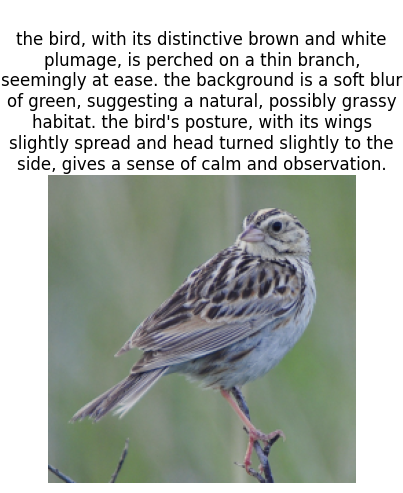

In [7]:
import matplotlib.pyplot as plt
import numpy as np

images, labels, captions = next(iter(train_loader))

img_tensor = images[0]
label_id = labels[0].item()
caption_text = captions[0]

def show_sample(img, title):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.cpu().numpy()

    img = img.transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(title, wrap=True)
    plt.axis('off')
    plt.show()

show_sample(img_tensor, title=f"{caption_text}")

In [8]:
from torch import nn
from transformers import CLIPModel, CLIPProcessor
from peft import LoraConfig, get_peft_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "openai/clip-vit-base-patch16"
base_model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none"
)

lora_model = get_peft_model(base_model, lora_config).to(device)

print("Thống kê tham số:")
lora_model.print_trainable_parameters()

# 2 hàm CrossEntropy để đối chiếu 2 chiều (Ảnh -> Chữ, Chữ -> Ảnh)
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(lora_model.parameters(), lr=1e-4, weight_decay=1e-3)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Thống kê tham số:
trainable params: 983,040 || all params: 150,603,777 || trainable%: 0.6527


In [9]:
import matplotlib.pyplot as plt
from tqdm import tqdm

num_epochs = 20
history_loss = []

print("BẮT ĐẦU FINE-TUNE CLIP + LoRA...")

for epoch in range(num_epochs):
    lora_model.train()
    running_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

    for images, _, captions in train_pbar:
        pixel_values = images.to(device)

        text_inputs = processor(
            text=list(captions),
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77
        )
        input_ids = text_inputs["input_ids"].to(device)
        attention_mask = text_inputs["attention_mask"].to(device)

        optimizer.zero_grad()

        # forward pass
        outputs = lora_model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits_per_image = outputs.logits_per_image
        logits_per_text = outputs.logits_per_text

        ground_truth = torch.arange(len(pixel_values), dtype=torch.long, device=device)
        total_loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2

        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
        train_pbar.set_postfix(loss=f"{total_loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    history_loss.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Contrastive Loss: {epoch_loss:.4f}")

    # lưu các tham số Adapter của LoRA
    lora_model.save_pretrained(f"/content/drive/MyDrive/ImageRetrieval/model/clip_lora_epoch_{epoch+1}")

print("Hoàn thành Fine-tune CLIP + LoRA!")

BẮT ĐẦU FINE-TUNE CLIP + LoRA...


Epoch [1/20] Contrastive Loss: 0.4175


Epoch [2/20] Contrastive Loss: 0.2013


Epoch [3/20] Contrastive Loss: 0.1454


Epoch [4/20] Contrastive Loss: 0.1202


...

Epoch [16/20] Contrastive Loss: 0.0436


Epoch [17/20] Contrastive Loss: 0.0394


Epoch [18/20] Contrastive Loss: 0.0435


Epoch [19/20] Contrastive Loss: 0.0360


Epoch [20/20] Contrastive Loss: 0.0407
Hoàn thành Fine-tune CLIP + LoRA!


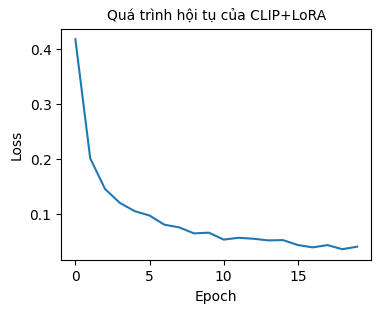

In [17]:
plt.figure(figsize=(4, 3))
plt.plot(history_loss, label='Contrastive Loss')
plt.title('Quá trình hội tụ của CLIP+LoRA', fontsize = 10)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig(fname='clip.png',dpi=400)
plt.show()